In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera, normaltest, shapiro

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Project_1_DGS10.csv to Project_1_DGS10.csv


**Шаг 1**

In [14]:
df = pd.read_csv("Project_1_DGS10.csv")

df["DATE"] = pd.to_datetime(df["DATE"])
df["DGS10"] = pd.to_numeric(df["DGS10"], errors="coerce")

print(df.head())
print(df.info())
print("Количество пропусков:", df["DGS10"].isna().sum())

df = df.dropna().sort_values("DATE").reset_index(drop=True)

df["dX"] = df["DGS10"].diff()
returns = df["dX"].dropna()

        DATE  DGS10
0 2019-11-07   1.92
1 2019-11-08   1.94
2 2019-11-11    NaN
3 2019-11-12   1.92
4 2019-11-13   1.88
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1306 entries, 0 to 1305
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    1306 non-null   datetime64[ns]
 1   DGS10   1252 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 20.5 KB
None
Количество пропусков: 54


График исторической выборки

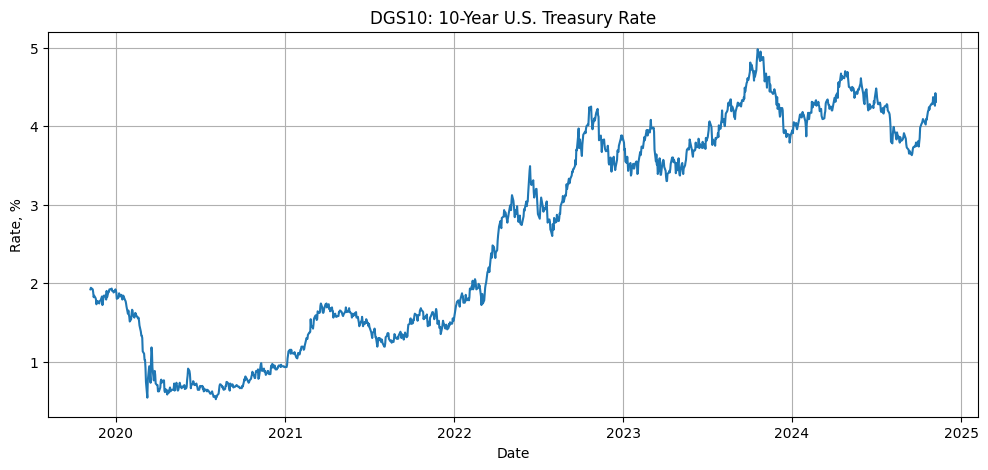

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["DGS10"])
plt.title("DGS10: 10-Year U.S. Treasury Rate")
plt.xlabel("Date")
plt.ylabel("Rate, %")
plt.grid()
plt.show()

График приращений

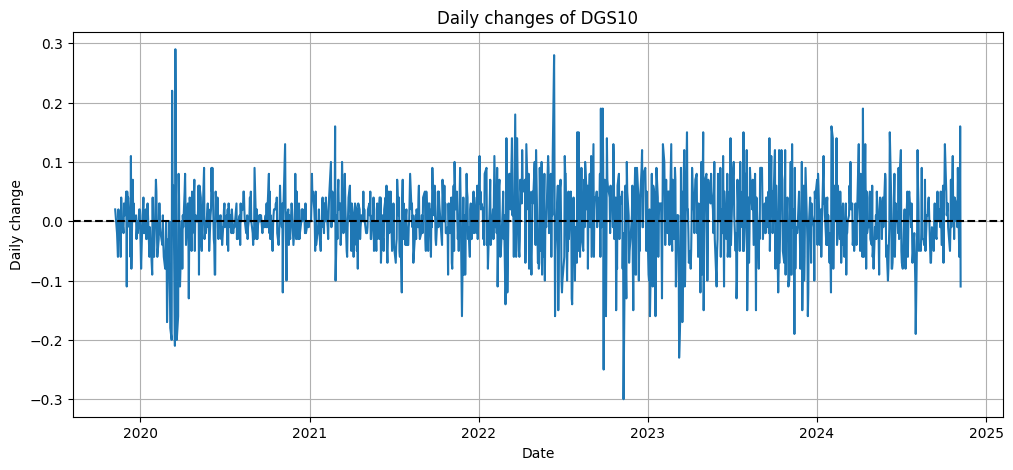

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["dX"])
plt.axhline(0, color="black", linestyle="--")
plt.title("Daily changes of DGS10")
plt.xlabel("Date")
plt.ylabel("Daily change")
plt.grid()
plt.show()

Характеристики

In [17]:
summary = pd.DataFrame({
    "mean": [df["DGS10"].mean(), returns.mean()],
    "variance": [df["DGS10"].var(), returns.var()],
    "std": [df["DGS10"].std(), returns.std()],
    "min": [df["DGS10"].min(), returns.min()],
    "max": [df["DGS10"].max(), returns.max()],
    "skewness": [stats.skew(df["DGS10"]), stats.skew(returns)],
    "kurtosis": [stats.kurtosis(df["DGS10"]), stats.kurtosis(returns)]
}, index=["DGS10", "dX"])

summary

,mean,variance,std,min,max,skewness,kurtosis
DGS10,2.616478,1.873328,1.368696,0.52,4.98,-0.024204,-1.560051
dX,0.001910,0.003941,0.062777,-0.30,0.29,-0.099363,1.580927


Анализ выбросов по IQR-критерию

In [18]:
q1 = returns.quantile(0.25)
q3 = returns.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["dX"] < lower) | (df["dX"] > upper)]

print("Нижняя граница:", lower)
print("Верхняя граница:", upper)
print("Количество выбросов:", len(outliers))

outliers[["DATE", "DGS10", "dX"]].head()

Нижняя граница: -0.13500000000000068
Верхняя граница: 0.14500000000000046
Количество выбросов: 45


,DATE,DGS10,dX
75,2020-02-28,1.13,-0.17
80,2020-03-06,0.74,-0.18
81,2020-03-09,0.54,-0.20
82,2020-03-10,0.76,0.22
86,2020-03-16,0.73,-0.21


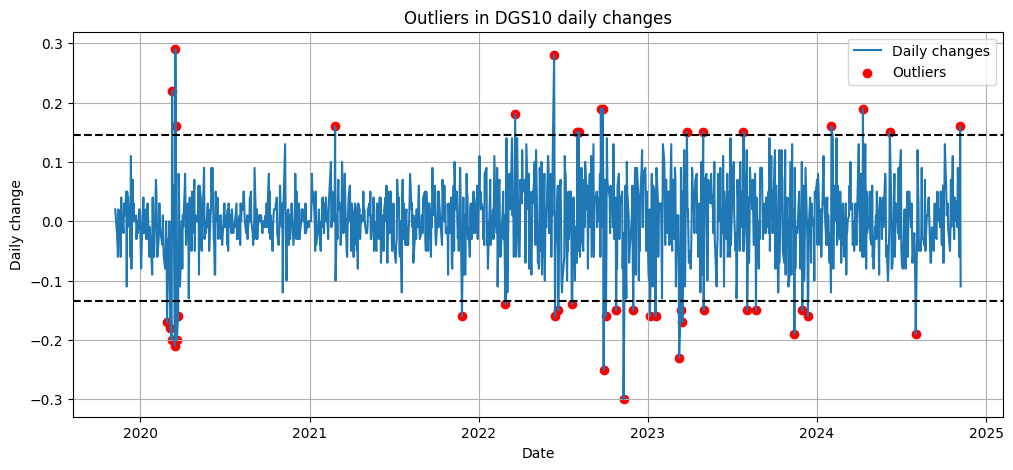

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["dX"], label="Daily changes")
plt.scatter(outliers["DATE"], outliers["dX"], color="red", label="Outliers")
plt.axhline(lower, color="black", linestyle="--")
plt.axhline(upper, color="black", linestyle="--")
plt.title("Outliers in DGS10 daily changes")
plt.xlabel("Date")
plt.ylabel("Daily change")
plt.legend()
plt.grid()
plt.show()

Можно заметить что много выбросов приходится на март 2020 года и период 2022–2023 годов, когда ставки менялись особенно резко

Проверка нормальности

In [21]:
jb_stat, jb_pvalue = jarque_bera(returns)
dagostino_stat, dagostino_pvalue = normaltest(returns)

# Shapiro лучше применять на подвыборке, потому что на больших выборках он почти всегда отвергает нормальность
sample_for_shapiro = returns.sample(min(500, len(returns)), random_state=42)
shapiro_stat, shapiro_pvalue = shapiro(sample_for_shapiro)

normality_tests = pd.DataFrame({
    "test": ["Jarque-Bera", "D'Agostino-Pearson", "Shapiro-Wilk, sample n=500"],
    "statistic": [jb_stat, dagostino_stat, shapiro_stat],
    "p_value": [jb_pvalue, dagostino_pvalue, shapiro_pvalue]
})

normality_tests

,test,statistic,p_value
0,Jarque-Bera,132.336203,1.834673e-29
1,D'Agostino-Pearson,48.770688,2.567909e-11
2,"Shapiro-Wilk, sample n=500",0.974431,1.152888e-07


Вывод: Все использованные тесты нормальности дают малые p-value, поэтому гипотеза нормальности приращений отвергается.

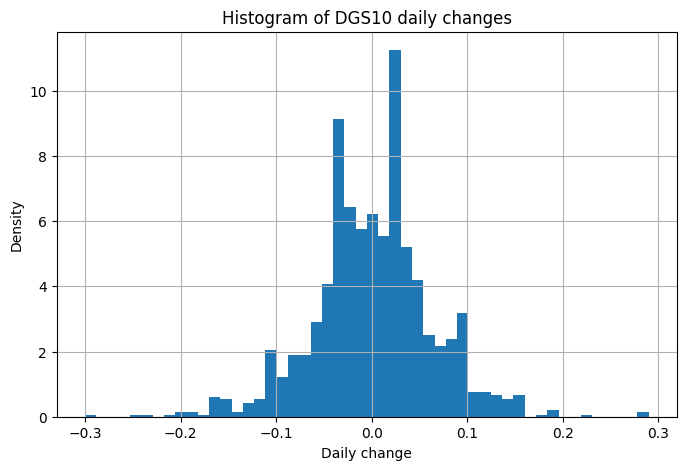

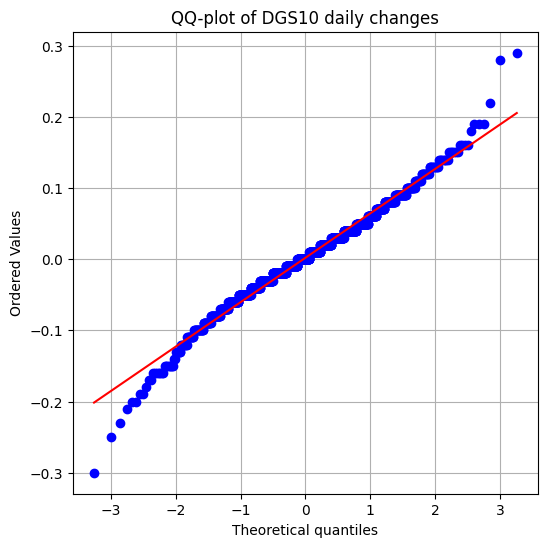

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(returns, bins=50, density=True)
plt.title("Histogram of DGS10 daily changes")
plt.xlabel("Daily change")
plt.ylabel("Density")
plt.grid()
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ-plot of DGS10 daily changes")
plt.grid()
plt.show()

Change points

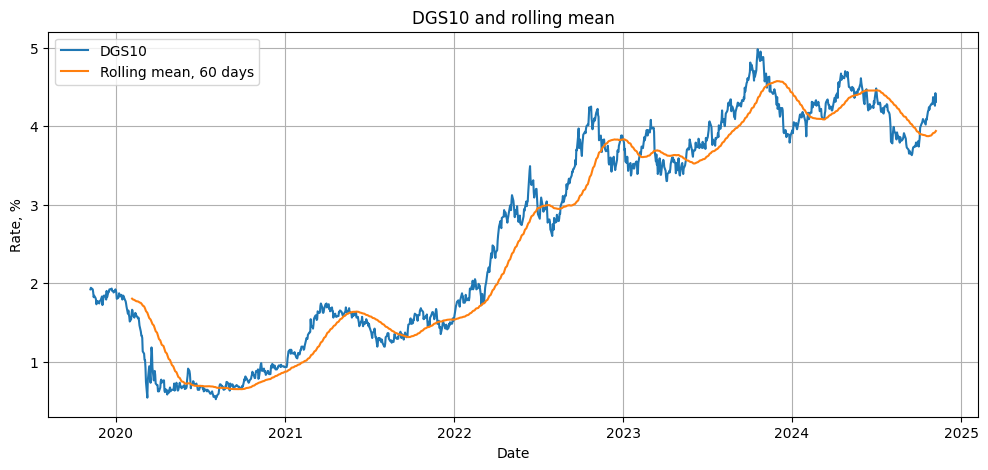

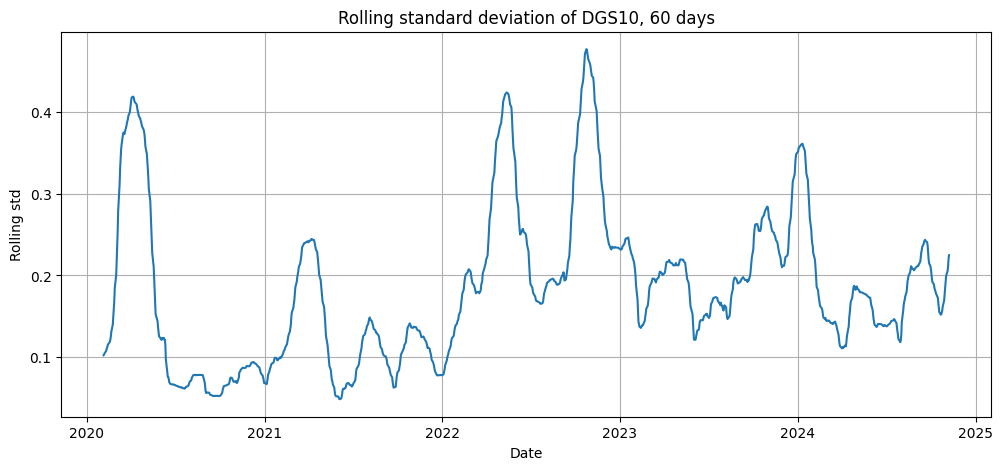

In [24]:
window = 60

df["rolling_mean"] = df["DGS10"].rolling(window).mean()
df["rolling_std"] = df["DGS10"].rolling(window).std()

plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["DGS10"], label="DGS10")
plt.plot(df["DATE"], df["rolling_mean"], label="Rolling mean, 60 days")
plt.title("DGS10 and rolling mean")
plt.xlabel("Date")
plt.ylabel("Rate, %")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["DATE"], df["rolling_std"])
plt.title("Rolling standard deviation of DGS10, 60 days")
plt.xlabel("Date")
plt.ylabel("Rolling std")
plt.grid()
plt.show()

Скользящее среднее показывает смену тенденции: сначала ставка снижается, затем находится на низком уровне, после чего переходит к растущему тренду. Скользящее стандартное отклонение показывает, что интенсивность колебаний также непостоянна. Поэтому в данных можно выделить несколько режимов, а одна модель с постоянными параметрами будет описывать весь период только приближённо.

**Шаг 2**

In [26]:
from scipy.optimize import minimize

In [27]:
# Ряд, который будем моделировать
x = df["DGS10"].values

x = x[x > 0]

dt = 1 / 252
n = len(x)

print("Number of observations:", n)
print("dt:", dt)
print("First observations:", x[:5])

Number of observations: 1252
dt: 0.003968253968253968
First observations: [1.92 1.94 1.92 1.88 1.82]


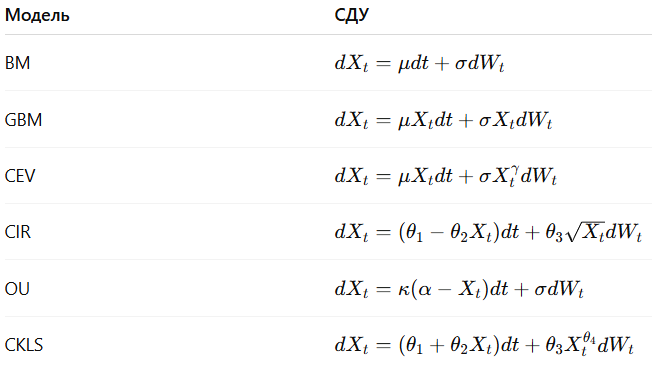

In [28]:
eps = 1e-8

def safe_x(x):
    return np.maximum(x, eps)

In [29]:
models = {
    "BM": {
        "params": ["mu", "sigma"],
        "x0": np.array([0.0, 0.1]),
        "bounds": [(None, None), (eps, None)],

        "b": lambda x, p: p[0],
        "sigma": lambda x, p: p[1],
        "b_x": lambda x, p: 0.0,
        "b_xx": lambda x, p: 0.0,
        "sigma_x": lambda x, p: 0.0,
        "sigma_xx": lambda x, p: 0.0,
    },

    "GBM": {
        "params": ["mu", "sigma"],
        "x0": np.array([0.0, 0.1]),
        "bounds": [(None, None), (eps, None)],

        "b": lambda x, p: p[0] * x,
        "sigma": lambda x, p: p[1] * safe_x(x),
        "b_x": lambda x, p: p[0],
        "b_xx": lambda x, p: 0.0,
        "sigma_x": lambda x, p: p[1],
        "sigma_xx": lambda x, p: 0.0,
    },

    "CEV": {
        "params": ["mu", "sigma", "gamma"],
        "x0": np.array([0.0, 0.1, 1.0]),
        "bounds": [(None, None), (eps, None), (0.0, 3.0)],

        "b": lambda x, p: p[0] * x,
        "sigma": lambda x, p: p[1] * safe_x(x)**p[2],
        "b_x": lambda x, p: p[0],
        "b_xx": lambda x, p: 0.0,
        "sigma_x": lambda x, p: p[1] * p[2] * safe_x(x)**(p[2] - 1),
        "sigma_xx": lambda x, p: p[1] * p[2] * (p[2] - 1) * safe_x(x)**(p[2] - 2),
    },

    "CIR": {
        "params": ["theta1", "theta2", "theta3"],
        "x0": np.array([1.0, 1.0, 0.1]),
        "bounds": [(eps, None), (eps, None), (eps, None)],

        "b": lambda x, p: p[0] - p[1] * x,
        "sigma": lambda x, p: p[2] * np.sqrt(safe_x(x)),
        "b_x": lambda x, p: -p[1],
        "b_xx": lambda x, p: 0.0,
        "sigma_x": lambda x, p: p[2] / (2 * np.sqrt(safe_x(x))),
        "sigma_xx": lambda x, p: -p[2] / (4 * safe_x(x)**1.5),
    },

    "OU": {
        "params": ["kappa", "alpha", "sigma"],
        "x0": np.array([1.0, np.mean(x), 0.1]),
        "bounds": [(eps, None), (None, None), (eps, None)],

        "b": lambda x, p: p[0] * (p[1] - x),
        "sigma": lambda x, p: p[2],
        "b_x": lambda x, p: -p[0],
        "b_xx": lambda x, p: 0.0,
        "sigma_x": lambda x, p: 0.0,
        "sigma_xx": lambda x, p: 0.0,
    },

    "CKLS": {
        "params": ["theta1", "theta2", "theta3", "theta4"],
        "x0": np.array([1.0, -0.5, 0.1, 1.0]),
        "bounds": [(None, None), (None, None), (eps, None), (0.0, 3.0)],

        "b": lambda x, p: p[0] + p[1] * x,
        "sigma": lambda x, p: p[2] * safe_x(x)**p[3],
        "b_x": lambda x, p: p[1],
        "b_xx": lambda x, p: 0.0,
        "sigma_x": lambda x, p: p[2] * p[3] * safe_x(x)**(p[3] - 1),
        "sigma_xx": lambda x, p: p[2] * p[3] * (p[3] - 1) * safe_x(x)**(p[3] - 2),
    }
}

In [31]:
 #Каждое наблюдение X(i+1)приближённо считаем условно нормально распределённым при известном X(i). Разные методы отличаются тем, как задаются условные среднее и дисперсия.

def normal_logpdf(y, mean, var):
    if var <= 0 or np.isnan(var) or np.isinf(var):
        return -1e10
    return -0.5 * (np.log(2 * np.pi * var) + (y - mean)**2 / var)


In [32]:
def euler_log_density(y, x0, dt, p, model):
    b = model["b"](x0, p)
    s = model["sigma"](x0, p)

    mean = x0 + b * dt
    var = s**2 * dt

    return normal_logpdf(y, mean, var)


Метод Сёдзи–Озаки использует локальную линеаризацию сноса. Если производная bx близка к нулю, будем возвращаться к Эйлеру, чтобы избежать неустойчивости при делении на ноль.

In [33]:
def shoji_ozaki_log_density(y, x0, dt, p, model):
    b = model["b"](x0, p)
    bx = model["b_x"](x0, p)
    bxx = model["b_xx"](x0, p)
    s = model["sigma"](x0, p)

    if abs(bx) < 1e-6:
        return euler_log_density(y, x0, dt, p, model)

    M = 0.5 * s**2 * bxx

    mean = x0 + b / bx * (np.exp(bx * dt) - 1)
    mean = mean + M / bx**2 * (np.exp(bx * dt) - 1 - bx * dt)

    var = s**2 * (np.exp(2 * bx * dt) - 1) / (2 * bx)

    return normal_logpdf(y, mean, var)

In [34]:
def kessler_log_density(y, x0, dt, p, model):
    b = model["b"](x0, p)
    bx = model["b_x"](x0, p)
    bxx = model["b_xx"](x0, p)

    s = model["sigma"](x0, p)
    sx = model["sigma_x"](x0, p)
    sxx = model["sigma_xx"](x0, p)

    mean = x0 + b * dt + 0.5 * (b * bx + 0.5 * s**2 * bxx) * dt**2

    second_moment = (
        x0**2
        + (2 * b * x0 + s**2) * dt
        + 0.5 * (
            2 * b * (bx * x0 + b + s * sx)
            + s**2 * (bxx * x0 + 2 * bx + sx**2 + s * sxx)
        ) * dt**2
    )

    var = second_moment - mean**2

    return normal_logpdf(y, mean, var)

Минимизируем отрицательный логарифм правдоподобия


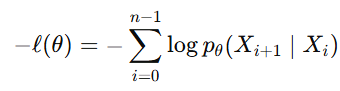

In [35]:
def neg_log_likelihood(p, x, dt, model, method):
    total = 0.0

    for i in range(len(x) - 1):
        x0 = x[i]
        y = x[i + 1]

        if method == "Euler":
            ll = euler_log_density(y, x0, dt, p, model)
        elif method == "Shoji-Ozaki":
            ll = shoji_ozaki_log_density(y, x0, dt, p, model)
        elif method == "Kessler":
            ll = kessler_log_density(y, x0, dt, p, model)
        else:
            raise ValueError("Unknown method")

        if np.isnan(ll) or np.isinf(ll):
            return 1e10

        total += ll

    return -total

In [36]:
methods = ["Euler", "Shoji-Ozaki", "Kessler"]

results = []

for model_name, model in models.items():
    for method in methods:

        res = minimize(
            neg_log_likelihood,
            x0=model["x0"],
            args=(x, dt, model, method),
            method="L-BFGS-B",
            bounds=model["bounds"]
        )

        row = {
            "model": model_name,
            "method": method,
            "success": res.success,
            "neg_log_likelihood": res.fun
        }

        for param_name, value in zip(model["params"], res.x):
            row[param_name] = value

        results.append(row)

results_df = pd.DataFrame(results)
results_df

,model,method,success,neg_log_likelihood,mu,sigma,gamma,theta1,theta2,theta3,kappa,alpha,theta4
0,BM,Euler,True,-1688.391476,0.481375,0.996151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BM,Shoji-Ozaki,True,-1688.391476,0.481375,0.996151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BM,Kessler,True,-1688.391476,0.481484,0.996151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GBM,Euler,True,-1356.425169,0.336820,0.594605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GBM,Shoji-Ozaki,True,-1356.425169,0.336595,0.594208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,GBM,Kessler,True,-1356.425169,0.336570,0.593606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CEV,Euler,True,-1714.446580,0.142830,0.818211,0.225184,NaN,NaN,NaN,NaN,NaN,NaN
7,CEV,Shoji-Ozaki,True,-1714.446580,0.142802,0.817979,0.225185,NaN,NaN,NaN,NaN,NaN,NaN
8,CEV,Kessler,True,-1714.444494,0.142790,0.818002,0.225121,NaN,NaN,NaN,NaN,NaN,NaN
9,CIR,Euler,True,-1670.551106,NaN,NaN,NaN,0.803420,0.123126,0.683672,NaN,NaN,NaN


Для каждой модели я задала коэффициент сноса b(x,θ) и коэффициент диффузии σ(x,θ). Затем для дискретных наблюдений построила приближённую условную нормальную плотность перехода. Параметры выбирались методом максимального правдоподобия, то есть минимизацией отрицательного логарифма правдоподобия. Я использовала три аппроксимации переходной плотности: Euler, Shoji–Ozaki и Kessler.

На параметры волатильности я наложила положительность, потому что коэффициент диффузии должен быть неотрицательным. Для CIR также параметры θ1, θ2, θ3 взяты положительными, так как это стандартная форма модели CIR. Для CEV и CKLS степень при Xt ограничена интервалом от 0 до 3, чтобы оптимизация не уходила в бессмысленные значения.

**Шаг 3**

In [38]:
param_table = results_df.drop(columns=["success", "neg_log_likelihood"])

pd.set_option("display.float_format", lambda x: f"{x:.6f}")

param_table

,model,method,mu,sigma,gamma,theta1,theta2,theta3,kappa,alpha,theta4
0,BM,Euler,0.481375,0.996151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BM,Shoji-Ozaki,0.481375,0.996151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BM,Kessler,0.481484,0.996151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GBM,Euler,0.336820,0.594605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GBM,Shoji-Ozaki,0.336595,0.594208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,GBM,Kessler,0.336570,0.593606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CEV,Euler,0.142830,0.818211,0.225184,NaN,NaN,NaN,NaN,NaN,NaN
7,CEV,Shoji-Ozaki,0.142802,0.817979,0.225185,NaN,NaN,NaN,NaN,NaN,NaN
8,CEV,Kessler,0.142790,0.818002,0.225121,NaN,NaN,NaN,NaN,NaN,NaN
9,CIR,Euler,NaN,NaN,NaN,0.803420,0.123126,0.683672,NaN,NaN,NaN


**Шаг 4**

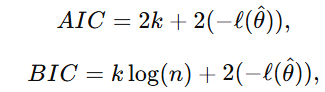

k-число параметров
n-число наблюдений

In [46]:
# Добавляем число параметров для каждой модели
results_df["num_params"] = results_df["model"].apply(
    lambda name: len(models[name]["params"])
)

# AIC и BIC считаются по отрицательному log-likelihood
results_df["AIC"] = 2 * results_df["num_params"] + 2 * results_df["neg_log_likelihood"]
results_df["BIC"] = (
    results_df["num_params"] * np.log(len(x) - 1)
    + 2 * results_df["neg_log_likelihood"]
)

criteria_table = results_df[
    ["model", "method", "neg_log_likelihood", "num_params", "AIC", "BIC"]
].copy()

criteria_table = criteria_table.sort_values("AIC").reset_index(drop=True)

criteria_table.round(4)

,model,method,neg_log_likelihood,num_params,AIC,BIC
0,CEV,Shoji-Ozaki,-1714.446600,3,-3422.893200,-3407.498100
1,CEV,Euler,-1714.446600,3,-3422.893200,-3407.498100
2,CEV,Kessler,-1714.444500,3,-3422.889000,-3407.493900
3,CKLS,Kessler,-1714.852900,4,-3421.705800,-3401.179000
4,CKLS,Euler,-1714.851000,4,-3421.702000,-3401.175200
5,CKLS,Shoji-Ozaki,-1714.851000,4,-3421.702000,-3401.175200
6,BM,Kessler,-1688.391500,2,-3372.783000,-3362.519600
7,BM,Euler,-1688.391500,2,-3372.783000,-3362.519600
8,BM,Shoji-Ozaki,-1688.391500,2,-3372.783000,-3362.519600
9,OU,Shoji-Ozaki,-1688.479100,3,-3370.958100,-3355.563000


In [47]:
best_aic = criteria_table.loc[criteria_table["AIC"].idxmin()]
best_bic = criteria_table.loc[criteria_table["BIC"].idxmin()]

print("Best model by AIC:")
print(best_aic)

print("\nBest model by BIC:")
print(best_bic)


Best model by AIC:
model                         CEV
method                Shoji-Ozaki
neg_log_likelihood   -1714.446580
num_params                      3
AIC                  -3422.893159
BIC                  -3407.498063
Name: 0, dtype: object

Best model by BIC:
model                         CEV
method                Shoji-Ozaki
neg_log_likelihood   -1714.446580
num_params                      3
AIC                  -3422.893159
BIC                  -3407.498063
Name: 0, dtype: object


По результатам вычисления AIC и BIC наилучшей моделью оказалась CEV-модель с аппроксимацией переходной плотности методом Сёдзи–Озаки. Для неё получены минимальные значения обоих критериев:
AIC=−3422.89, BIC=−3407.50.
Совпадение выбора по AIC и BIC говорит о достаточно устойчивом результате, так как AIC и BIC используют разные штрафы за сложность модели.

Наложение лучшей модели на данные по схеме Эйлера


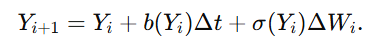

In [51]:
# Берём лучшую модель по AIC
best_row = criteria_table.iloc[0]

best_model_name = best_row["model"]
best_method = best_row["method"]

best_params = results_df[
    (results_df["model"] == best_model_name) &
    (results_df["method"] == best_method)
].iloc[0]

mu_hat = best_params["mu"]
sigma_hat = best_params["sigma"]
gamma_hat = best_params["gamma"]

print("mu =", mu_hat)
print("sigma =", sigma_hat)
print("gamma =", gamma_hat)

mu = 0.14280198779024414
sigma = 0.8179790427955257
gamma = 0.2251845352863362


In [52]:
def simulate_cev(x0, mu, sigma, gamma, dt, n, seed=42):
    np.random.seed(seed)

    path = np.zeros(n)
    path[0] = x0

    for i in range(n - 1):
        z = np.random.normal()
        x_current = max(path[i], 1e-8)

        drift = mu * x_current
        diffusion = sigma * (x_current ** gamma)

        path[i + 1] = path[i] + drift * dt + diffusion * np.sqrt(dt) * z

        # Ставка не должна становиться отрицательной
        if path[i + 1] <= 0:
            path[i + 1] = 1e-8

    return path

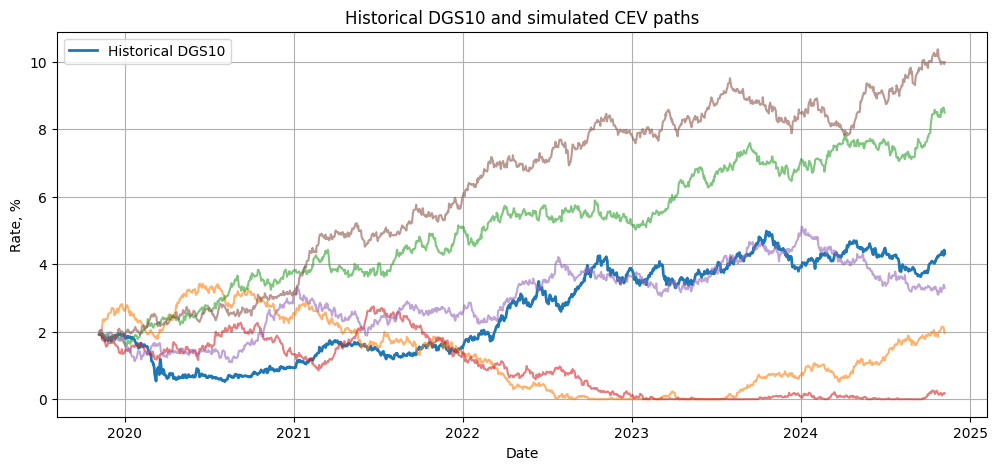

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(df["DATE"].iloc[:len(x)], x, label="Historical DGS10", linewidth=2)

for seed in range(5):
    path = simulate_cev(
        x0=x[0],
        mu=mu_hat,
        sigma=sigma_hat,
        gamma=gamma_hat,
        dt=dt,
        n=len(x),
        seed=seed
    )
    plt.plot(df["DATE"].iloc[:len(x)], path, alpha=0.6)

plt.title("Historical DGS10 and simulated CEV paths")
plt.xlabel("Date")
plt.ylabel("Rate, %")
plt.legend()
plt.grid()
plt.show()

Было смоделировано 5 вариантов тректорий.Траектории CEV не обязаны точно совпадать с историческим рядом, так как модель является стохастической. Однако график позволяет сравнить порядок величин, общую изменчивость и способность модели генерировать положительные значения ставки. CEV-модель воспроизводит положительность ряда и допускает зависимость волатильности от уровня ставки, что согласуется с природой процентных ставок.
Модель не полностью воспроизводит структурные сдвиги исторического ряда, выявленные ранее с помощью скользящего среднего и скользящего стандартного отклонения, поскольку в проекте используются модели с постоянными параметрами на всём периоде наблюдений.

**Шаг 5**

In [56]:
!pip install git+https://github.com/jkirkby3/pymle.git

  Cloning https://github.com/jkirkby3/pymle.git to /tmp/pip-req-build-wm013fim
  Running command git clone --filter=blob:none --quiet https://github.com/jkirkby3/pymle.git /tmp/pip-req-build-wm013fim
  Resolved https://github.com/jkirkby3/pymle.git to commit a68ee7b071a9eae8264c649719052ef711b47775
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pymle-diffusion: filename=pymle_diffusion-0.0.9-py3-none-any.whl size=41005 sha256=dd7cf8b6d34c8bab92bd57590739214a4adfa714d39bce584a2cf5d3c0e036be
  Stored in directory: /tmp/pip-ephem-wheel-cache-g_h5olkv/wheels/0f/13/f6/83871fe3ee3c6831f6f8cc5989c9221b42b526ca31c5d0bf18
Successfully built pymle-diffusion


In [57]:
import numpy as np
import pandas as pd

from pymle.fit.AnalyticalMLE import AnalyticalMLE
from pymle.core.TransitionDensity import EulerDensity, KesslerDensity, ShojiOzakiDensity

from pymle.models.BrownianMotion import BrownianMotion
from pymle.models.GeometricBM import GeometricBM
from pymle.models.CEV import CEV
from pymle.models.CIR import CIR
from pymle.models.OrnsteinUhlenbeck import OrnsteinUhlenbeck
from pymle.models.CKLS import CKLS

In [58]:
sample = x.copy()
dt = 1 / 252

print("Sample length:", len(sample))
print("dt:", dt)

Sample length: 1252
dt: 0.003968253968253968


Функция для оценивания моделей

In [59]:
def fit_pymle_model(model_name, model, guess, bounds):
    densities = {
        "Euler": EulerDensity(model),
        "Shoji-Ozaki": ShojiOzakiDensity(model),
        "Kessler": KesslerDensity(model)
    }

    rows = []

    for method_name, density in densities.items():
        try:
            estimator = AnalyticalMLE(
                sample=sample,
                param_bounds=bounds,
                dt=dt,
                density=density
            )

            estimate = estimator.estimate_params(guess)

            row = {
                "model": model_name,
                "method": method_name,
                "success": True,
                "estimate": estimate
            }

        except Exception as e:
            row = {
                "model": model_name,
                "method": method_name,
                "success": False,
                "estimate": None,
                "error": str(e)
            }

        rows.append(row)

    return rows

In [87]:
pymle_results = []


In [88]:
model = BrownianMotion()
guess = np.array([0.4, 1.0])
bounds = [(-10, 10), (1e-8, 10)]

pymle_results += fit_pymle_model("BM", model, guess, bounds)

Initial Params: [0.4 1. ]
Initial Likelihood: 1688.3564463422067
`xtol` termination condition is satisfied.
Number of iterations: 38, function evaluations: 105, CG iterations: 52, optimality: 3.00e-05, constraint violation: 0.00e+00, execution time: 0.12 s.
Final Params: [0.48144083 0.99614997]
Final Likelihood: 1688.391475753754
Initial Params: [0.4 1. ]
Initial Likelihood: 1688.3564463422067


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 31, function evaluations: 57, CG iterations: 41, optimality: 1.49e-05, constraint violation: 0.00e+00, execution time: 0.096 s.
Final Params: [0.48143937 0.99614996]
Final Likelihood: 1688.391475753763
Initial Params: [0.4 1. ]
Initial Likelihood: 1688.356446342225
`xtol` termination condition is satisfied.
Number of iterations: 30, function evaluations: 87, CG iterations: 44, optimality: 2.55e-03, constraint violation: 0.00e+00, execution time: 0.093 s.
Final Params: [0.48136663 0.99615127]
Final Likelihood: 1688.391475738541


In [89]:
model = GeometricBM()
guess = np.array([0.3, 0.6])
bounds = [(-10, 10), (1e-8, 10)]

pymle_results += fit_pymle_model("GBM", model, guess, bounds)

Initial Params: [0.3 0.6]
Initial Likelihood: 1356.3143809451071
`xtol` termination condition is satisfied.
Number of iterations: 31, function evaluations: 57, CG iterations: 32, optimality: 1.50e-05, constraint violation: 0.00e+00, execution time: 0.08 s.
Final Params: [0.33680865 0.59460505]
Final Likelihood: 1356.425169078743
Initial Params: [0.3 0.6]
Initial Likelihood: 1356.3007136189474
`xtol` termination condition is satisfied.
Number of iterations: 34, function evaluations: 96, CG iterations: 45, optimality: 2.67e-01, constraint violation: 0.00e+00, execution time: 0.097 s.
Final Params: [0.33662945 0.59420878]
Final Likelihood: 1356.4251690658643
Initial Params: [0.3 0.6]
Initial Likelihood: 1355.0977165954832
`xtol` termination condition is satisfied.
Number of iterations: 26, function evaluations: 75, CG iterations: 42, optimality: 5.09e+00, constraint violation: 0.00e+00, execution time: 0.075 s.
Final Params: [0.30067563 0.59281789]
Final Likelihood: 1355.2964005317122


In [90]:
model = CEV()

guess = np.array([0.0, 0.14, 0.82, 0.23])
bounds = [(-1e-8, 1e-8), (-10, 10), (1e-8, 10), (0, 3)]

pymle_results += fit_pymle_model("CEV", model, guess, bounds)

Initial Params: [0.   0.14 0.82 0.23]
Initial Likelihood: 1714.0167243371895
`gtol` termination condition is satisfied.
Number of iterations: 37, function evaluations: 150, CG iterations: 79, optimality: 5.69e-07, constraint violation: 0.00e+00, execution time: 0.15 s.
Final Params: [-3.37777880e-13  1.39986788e-01  8.18663183e-01  2.24861255e-01]
Final Likelihood: 1714.0710196036557
Initial Params: [0.   0.14 0.82 0.23]
Initial Likelihood: 1714.0167243371898
`xtol` termination condition is satisfied.
Number of iterations: 40, function evaluations: 190, CG iterations: 88, optimality: 7.12e-01, constraint violation: 0.00e+00, execution time: 0.16 s.
Final Params: [4.94588230e-12 1.43554747e-01 8.17991617e-01 2.24821069e-01]
Final Likelihood: 1714.0709524859658
Initial Params: [0.   0.14 0.82 0.23]
Initial Likelihood: 1714.0132441265537
`xtol` termination condition is satisfied.
Number of iterations: 53, function evaluations: 320, CG iterations: 124, optimality: 4.78e+00, constraint viol

In [91]:
model = CIR()
guess = np.array([0.12, 6.5, 0.68])
bounds = [(1e-8, 10), (1e-8, 20), (1e-8, 10)]

pymle_results += fit_pymle_model("CIR", model, guess, bounds)

Initial Params: [0.12 6.5  0.68]
Initial Likelihood: 1670.513657549393
`xtol` termination condition is satisfied.
Number of iterations: 60, function evaluations: 192, CG iterations: 100, optimality: 6.93e-06, constraint violation: 0.00e+00, execution time: 0.18 s.
Final Params: [0.12311888 6.52547676 0.68367189]
Final Likelihood: 1670.5511057647022
Initial Params: [0.12 6.5  0.68]
Initial Likelihood: 1670.510344290677
`xtol` termination condition is satisfied.
Number of iterations: 28, function evaluations: 104, CG iterations: 61, optimality: 1.42e-02, constraint violation: 0.00e+00, execution time: 0.091 s.
Final Params: [0.12454602 6.50024427 0.68384533]
Final Likelihood: 1670.5510587687795
Initial Params: [0.12 6.5  0.68]
Initial Likelihood: 1670.7686871775113
`xtol` termination condition is satisfied.
Number of iterations: 30, function evaluations: 100, CG iterations: 45, optimality: 1.21e+00, constraint violation: 0.00e+00, execution time: 0.084 s.
Final Params: [0.1347666  6.5002

In [92]:
model = OrnsteinUhlenbeck()
guess = np.array([0.14, 6.1, 1.0])
bounds = [(1e-8, 10), (-20, 20), (1e-8, 10)]

pymle_results += fit_pymle_model("OU", model, guess, bounds)

Initial Params: [0.14 6.1  1.  ]
Initial Likelihood: 1688.4596702537938
`xtol` termination condition is satisfied.
Number of iterations: 51, function evaluations: 152, CG iterations: 105, optimality: 2.43e-06, constraint violation: 0.00e+00, execution time: 0.16 s.
Final Params: [0.13680078 6.13441131 0.99608022]
Final Likelihood: 1688.4790672500162
Initial Params: [0.14 6.1  1.  ]
Initial Likelihood: 1688.462298495316
`xtol` termination condition is satisfied.
Number of iterations: 34, function evaluations: 128, CG iterations: 79, optimality: 1.44e-02, constraint violation: 0.00e+00, execution time: 0.11 s.
Final Params: [0.13831237 6.10246735 0.996356  ]
Final Likelihood: 1688.4790555806098
Initial Params: [0.14 6.1  1.  ]
Initial Likelihood: 1688.4595979507153
`xtol` termination condition is satisfied.
Number of iterations: 37, function evaluations: 128, CG iterations: 81, optimality: 3.23e-04, constraint violation: 0.00e+00, execution time: 0.11 s.
Final Params: [0.1380116  6.10035

In [93]:
model = CKLS()
guess = np.array([0.74, -0.10, 0.82, 0.23])
bounds = [(-20, 20), (-20, 20), (1e-8, 10), (0, 3)]

pymle_results += fit_pymle_model("CKLS", model, guess, bounds)

Initial Params: [ 0.74 -0.1   0.82  0.23]
Initial Likelihood: 1714.7911320619323
`gtol` termination condition is satisfied.
Number of iterations: 37, function evaluations: 150, CG iterations: 72, optimality: 5.69e-07, constraint violation: 0.00e+00, execution time: 0.18 s.
Final Params: [ 0.73673541 -0.09880156  0.81771169  0.22555164]
Final Likelihood: 1714.8509939717906
Initial Params: [ 0.74 -0.1   0.82  0.23]
Initial Likelihood: 1714.7941727838108
`xtol` termination condition is satisfied.
Number of iterations: 22, function evaluations: 85, CG iterations: 39, optimality: 1.24e-01, constraint violation: 0.00e+00, execution time: 0.099 s.
Final Params: [ 0.74000349 -0.09979508  0.81786689  0.22556096]
Final Likelihood: 1714.8509866269942
Initial Params: [ 0.74 -0.1   0.82  0.23]
Initial Likelihood: 1714.7894591392705
`xtol` termination condition is satisfied.
Number of iterations: 28, function evaluations: 155, CG iterations: 81, optimality: 1.67e+00, constraint violation: 0.00e+00, 

In [96]:
pymle_raw = pd.DataFrame(pymle_results)

rows = []

for _, row in pymle_raw.iterrows():
    new_row = {
        "model": row["model"],
        "method": row["method"],
        "success": row["success"]
    }

    if row["success"]:
        est = row["estimate"]

        try:
            params = est.params
        except:
            params = np.array(est)

        for i, value in enumerate(params):
            new_row[f"param_{i+1}"] = value

        try:
            new_row["log_likelihood"] = est.log_like
        except:
            pass

    else:
        new_row["error"] = row.get("error", "")

    rows.append(new_row)

pymle_table = pd.DataFrame(rows)
pymle_table

,model,method,success,param_1,param_2,log_likelihood,param_3,param_4
0,BM,Euler,True,0.481441,0.996150,1688.391476,NaN,NaN
1,BM,Shoji-Ozaki,True,0.481439,0.996150,1688.391476,NaN,NaN
2,BM,Kessler,True,0.481367,0.996151,1688.391476,NaN,NaN
3,GBM,Euler,True,0.336809,0.594605,1356.425169,NaN,NaN
4,GBM,Shoji-Ozaki,True,0.336629,0.594209,1356.425169,NaN,NaN
5,GBM,Kessler,True,0.300676,0.592818,1355.296401,NaN,NaN
6,CIR,Euler,True,0.123119,6.525477,1670.551106,0.683672,NaN
7,CIR,Shoji-Ozaki,True,0.124546,6.500244,1670.551059,0.683845,NaN
8,CIR,Kessler,True,0.134767,6.500277,1670.802486,0.682791,NaN
9,OU,Euler,True,0.136801,6.134411,1688.479067,0.996080,NaN


In [99]:
# Число параметров для моделей pymle
pymle_num_params = {
    "BM": 2,
    "GBM": 2,
    "CEV": 3,
    "CIR": 3,
    "OU": 3,
    "CKLS": 4
}

pymle_criteria = pymle_table[pymle_table["success"] == True].copy()

pymle_criteria["num_params"] = pymle_criteria["model"].map(pymle_num_params)

pymle_criteria["AIC"] = -2 * pymle_criteria["log_likelihood"] + 2 * pymle_criteria["num_params"]
pymle_criteria["BIC"] = -2 * pymle_criteria["log_likelihood"] + pymle_criteria["num_params"] * np.log(len(sample) - 1)

pymle_criteria = pymle_criteria[
    ["model", "method", "log_likelihood", "num_params", "AIC", "BIC"]
].sort_values("AIC").reset_index(drop=True)

pymle_criteria.round(4)

,model,method,log_likelihood,num_params,AIC,BIC
0,CEV,Euler,1714.071000,3,-3422.142000,-3406.746900
1,CEV,Shoji-Ozaki,1714.071000,3,-3422.141900,-3406.746800
2,CEV,Kessler,1714.070000,3,-3422.139900,-3406.744800
3,CKLS,Kessler,1714.853300,4,-3421.706600,-3401.179800
4,CKLS,Euler,1714.851000,4,-3421.702000,-3401.175200
5,CKLS,Shoji-Ozaki,1714.851000,4,-3421.702000,-3401.175200
6,BM,Shoji-Ozaki,1688.391500,2,-3372.783000,-3362.519600
7,BM,Euler,1688.391500,2,-3372.783000,-3362.519600
8,BM,Kessler,1688.391500,2,-3372.783000,-3362.519600
9,OU,Euler,1688.479100,3,-3370.958100,-3355.563000


В pymle CEV задаётся в четырёхпараметрической форме. Чтобы получить стандартную CEV-модель, первый параметр дрейфа был зафиксирован около нуля с помощью узких границ. Поэтому при расчёте AIC и BIC число свободных параметров CEV считается равным 3.

In [100]:
best_pymle_aic = pymle_criteria.loc[pymle_criteria["AIC"].idxmin()]
best_pymle_bic = pymle_criteria.loc[pymle_criteria["BIC"].idxmin()]

print("Best pymle model by AIC:")
print(best_pymle_aic)

print("\nBest pymle model by BIC:")
print(best_pymle_bic)

Best pymle model by AIC:
model                     CEV
method                  Euler
log_likelihood    1714.071020
num_params                  3
AIC              -3422.142039
BIC              -3406.746944
Name: 0, dtype: object

Best pymle model by BIC:
model                     CEV
method                  Euler
log_likelihood    1714.071020
num_params                  3
AIC              -3422.142039
BIC              -3406.746944
Name: 0, dtype: object


В собственной реализации минимальные значения AIC и BIC были получены для CEV-модели с методом Сёдзи–Озаки. При повторном оценивании с использованием библиотеки pymle после фиксации первого параметра CEV-модели около нуля также была выбрана CEV-модель, но с методом Эйлера. Значения критериев отличаются незначительно, что объясняется малым шагом дискретизации ежедневных наблюдений. Следовательно, основной вывод устойчив: среди рассмотренных моделей динамику DGS10 лучше всего описывает CEV-модель.

Оценка параметра степени γ в CEV оказалась около 0.225. Это означает, что волатильность зависит от уровня ставки, но слабее, чем в CIR, где степень равна 1/2, и слабее, чем в GBM, где степень равна 1. Поэтому CEV оказалась более гибкой моделью для рассматриваемых данных.

**Шаг 6**

In [101]:
best_original = results_df[
    (results_df["model"] == "CEV") &
    (results_df["method"] == "Shoji-Ozaki")
].iloc[0]

mu_orig = best_original["mu"]
sigma_orig = best_original["sigma"]
gamma_orig = best_original["gamma"]

print("Original code CEV parameters:")
print("mu =", mu_orig)
print("sigma =", sigma_orig)
print("gamma =", gamma_orig)

Original code CEV parameters:
mu = 0.14280198779024414
sigma = 0.8179790427955257
gamma = 0.2251845352863362


In [102]:
best_pymle_cev = pymle_table[
    (pymle_table["model"] == "CEV") &
    (pymle_table["method"] == "Euler")
].iloc[0]

theta1_pymle = best_pymle_cev["param_1"]
mu_pymle = best_pymle_cev["param_2"]
sigma_pymle = best_pymle_cev["param_3"]
gamma_pymle = best_pymle_cev["param_4"]

print("pymle CEV parameters:")
print("theta1 =", theta1_pymle)
print("mu =", mu_pymle)
print("sigma =", sigma_pymle)
print("gamma =", gamma_pymle)

pymle CEV parameters:
theta1 = -3.3777788000293404e-13
mu = 0.13998678805593767
sigma = 0.8186631830166856
gamma = 0.22486125524539216


In [103]:
def simulate_cev(x0, mu, sigma, gamma, dt, n, seed=42):
    np.random.seed(seed)

    path = np.zeros(n)
    path[0] = x0

    for i in range(n - 1):
        z = np.random.normal()
        x_current = max(path[i], 1e-8)

        drift = mu * x_current
        diffusion = sigma * (x_current ** gamma)

        path[i + 1] = path[i] + drift * dt + diffusion * np.sqrt(dt) * z

        if path[i + 1] <= 0:
            path[i + 1] = 1e-8

    return path

In [104]:
cev_original_path = simulate_cev(
    x0=x[0],
    mu=mu_orig,
    sigma=sigma_orig,
    gamma=gamma_orig,
    dt=dt,
    n=len(x),
    seed=42
)

cev_pymle_path = simulate_cev(
    x0=x[0],
    mu=mu_pymle,
    sigma=sigma_pymle,
    gamma=gamma_pymle,
    dt=dt,
    n=len(x),
    seed=42
)

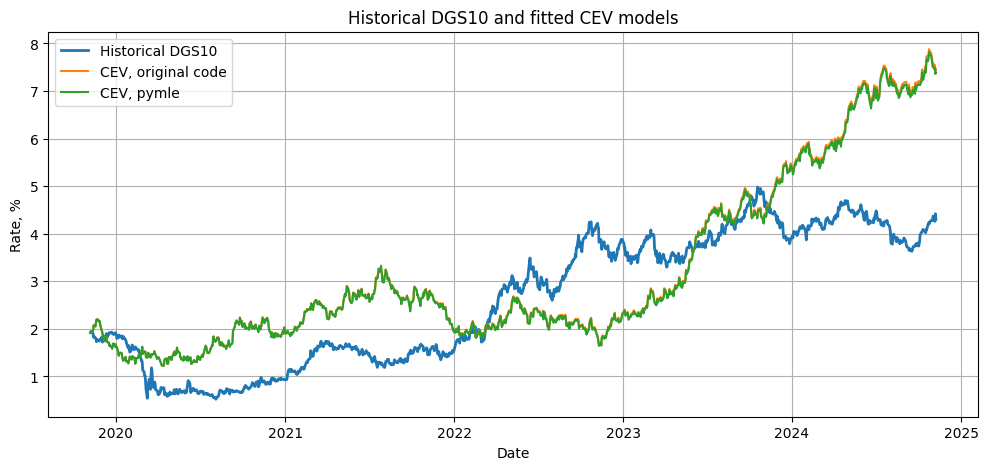

In [105]:
plt.figure(figsize=(12, 5))

plt.plot(df["DATE"].iloc[:len(x)], x, label="Historical DGS10", linewidth=2)
plt.plot(df["DATE"].iloc[:len(x)], cev_original_path, label="CEV, original code")
plt.plot(df["DATE"].iloc[:len(x)], cev_pymle_path, label="CEV, pymle")

plt.title("Historical DGS10 and fitted CEV models")
plt.xlabel("Date")
plt.ylabel("Rate, %")
plt.legend()
plt.grid()
plt.show()

Одна траектория недостаточно наглядна, смоделируем несколько

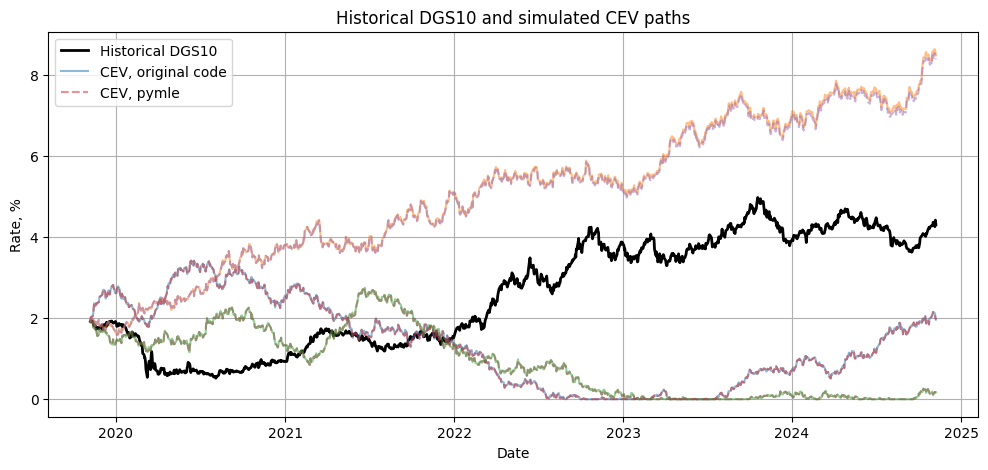

In [108]:
plt.figure(figsize=(12, 5))

dates = df["DATE"].iloc[:len(x)]

plt.plot(dates, x, label="Historical DGS10", linewidth=2, color="black")

# CEV: original code
for seed in range(3):
    path = simulate_cev(
        x0=x[0],
        mu=mu_orig,
        sigma=sigma_orig,
        gamma=gamma_orig,
        dt=dt,
        n=len(x),
        seed=seed
    )
    label = "CEV, original code" if seed == 0 else None
    plt.plot(dates, path, alpha=0.5, linestyle="-", label=label)

# CEV: pymle
for seed in range(3):
    path = simulate_cev(
        x0=x[0],
        mu=mu_pymle,
        sigma=sigma_pymle,
        gamma=gamma_pymle,
        dt=dt,
        n=len(x),
        seed=seed
    )
    label = "CEV, pymle" if seed == 0 else None
    plt.plot(dates, path, alpha=0.5, linestyle="--", label=label)

plt.title("Historical DGS10 and simulated CEV paths")
plt.xlabel("Date")
plt.ylabel("Rate, %")
plt.legend()
plt.grid()
plt.show()

На графике наложены исторический ряд DGS10 и смоделированные траектории CEV-модели с параметрами, полученными двумя способами: собственной реализацией и библиотекой pymle. Для одинаковых начальных значений и одинаковых случайных шумов траектории практически совпадают. Это объясняется тем, что оценки параметров в двух реализациях оказались очень близкими. Следовательно, библиотечная реализация подтверждает результаты, полученные собственным кодом.

**Шаг 7. Выводы**

В работе были исследованы ежедневные данные DGS10 за период 2019–2024 гг. На первом этапе был построен график исторического ряда и рассчитаны характеристики приращений. Проверка нормальности показала, что приращения ставки не являются нормально распределёнными: в данных присутствуют тяжёлые хвосты и выбросы. Наиболее заметные выбросы соответствуют периодам резких изменений ставок, в частности 2020 году и периоду 2022–2023 гг.

Анализ скользящего среднего и скользящего стандартного отклонения показал, что ряд содержит смены тенденции и изменение локальной волатильности. Поэтому модели с постоянными параметрами могут описывать весь период только приближённо.

Далее были оценены параметры моделей BM, GBM, CEV, CIR, OU и CKLS методом максимального правдоподобия с использованием трёх аппроксимаций переходной плотности: Euler, Shoji–Ozaki и Kessler. По результатам собственной реализации минимальные значения AIC и BIC были получены для CEV-модели с методом Shoji–Ozaki.

Затем оценивание было повторено с использованием библиотеки pymle. После фиксации первого параметра CEV около нуля библиотечная реализация также выбрала CEV-модель, но с методом Euler. Значения AIC и BIC оказались близкими к значениям собственной реализации, что подтверждает устойчивость результата.

Полученная оценка параметра степени gamma около 0.225 показывает, что волатильность зависит от уровня ставки, но слабее, чем в CIR, где степень равна 1/2, и слабее, чем в GBM, где степень равна 1. Поэтому CEV оказалась более гибкой моделью для рассматриваемых данных.

На графиках были наложены исторический ряд DGS10 и смоделированные траектории CEV. Траектории, полученные по параметрам собственной реализации и pymle, практически совпадают при одинаковом случайном шуме, что говорит о близости оценок параметров. При этом модель не повторяет историческую траекторию в точности, так как СДУ задаёт вероятностную динамику процесса.